# Chest X-Ray Dataset Analysis

This notebook explores and prepares a chest X-ray dataset for multi-label image classification.

The analysis includes:

- Loading X-ray metadata
- Understanding diagnosis labels
- Analyzing class distribution
- Analyzing patients and repeated X-rays
- Validating image availability
- Cleaning unmatched records
- Visualizing chest X-rays with their labels
- Preparing the dataset for future model training

## 1. Setup and Mount Google Drive

In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


## 2. Extract Dataset

In [3]:
!mkdir -p /content/dataset
!unzip -q "/content/drive/MyDrive/dataset/archive.zip" -d "/content/dataset"

print("Dataset extracted successfully")

Dataset extracted successfully


## 3. Load Ground Truth Metadata

In [4]:
import pandas as pd

csv_path = "/content/dataset/Chest_XRay_Dataset/Ground_Truth.csv"

df = pd.read_csv(csv_path)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

display(df.head(10))

Dataset shape: (111010, 6)

Columns:
['Image Index', 'Finding Labels', 'Patient ID', 'Patient Age', 'Patient Gender', 'View Position']


,Image Index,Finding Labels,Patient ID,Patient Age,Patient Gender,View Position
0,00000248_005.png,Atelectasis|Effusion|Mass,248,87,M,AP
1,00000248_006.png,Atelectasis|Infiltration,248,87,M,AP
2,00000248_007.png,Atelectasis|Infiltration,248,87,M,AP
3,00000248_008.png,Atelectasis,248,87,M,AP
4,00000248_009.png,Atelectasis,248,87,M,AP
5,00000248_010.png,Atelectasis,248,87,M,AP
6,00000248_011.png,No Finding,248,87,M,AP
7,00000248_012.png,No Finding,248,87,M,PA
8,00000248_013.png,Mass,248,87,M,AP
9,00000248_014.png,Effusion|Pleural_Thickening,248,87,M,AP


## 4. Dataset Overview

In [7]:
print("Total X-ray records:", len(df))
print("Unique patients:", df["Patient ID"].nunique())

print("\nAverage X-rays per patient:")
print(round(len(df) / df["Patient ID"].nunique(), 2))

Total X-ray records: 111010
Unique patients: 30538

Average X-rays per patient:
3.64


## 5. Finding Label Analysis

The dataset contains 14 abnormal chest findings plus a `No Finding` label.

Because multiple findings can appear in a single image, such as:

`Atelectasis|Effusion|Mass`

this is a **multi-label classification problem**, rather than a standard single-class classification problem.

In [8]:
all_labels = set()

for labels in df["Finding Labels"]:
    for label in labels.split("|"):
        all_labels.add(label)

all_labels = sorted(all_labels)

print("Total unique labels:", len(all_labels))

for label in all_labels:
    print(label)

Total unique labels: 15
Atelectasis
Cardiomegaly
Consolidation
Edema
Effusion
Emphysema
Fibrosis
Hernia
Infiltration
Mass
No Finding
Nodule
Pleural_Thickening
Pneumonia
Pneumothorax


## 6. Class Distribution in Full Metadata

In [9]:
from collections import Counter

label_counts = Counter()

for labels in df["Finding Labels"]:
    for label in labels.split("|"):
        label_counts[label] += 1

print("Number of images for each label:\n")

for label, count in label_counts.most_common():
    print(f"{label:20} {count}")

Number of images for each label:

No Finding           59932
Infiltration         19707
Effusion             13127
Atelectasis          11456
Nodule               6290
Mass                 5741
Pneumothorax         5254
Consolidation        4619
Pleural_Thickening   3347
Cardiomegaly         2679
Emphysema            2474
Edema                2270
Fibrosis             1647
Pneumonia            1418
Hernia               116


## 7. Patient-Level Analysis

Multiple X-rays may belong to the same patient.

For future model training, train/validation/test splitting should therefore be performed at the **patient level**, rather than randomly splitting individual images.

This helps prevent data leakage where X-rays from the same patient appear in both training and testing datasets.

In [10]:
patient_counts = df["Patient ID"].value_counts()

print("Top 20 patients with most X-rays:")
print(patient_counts.head(20))

Top 20 patients with most X-rays:
Patient ID
10007    184
13670    173
15530    158
12834    157
13993    143
1836     137
19124    130
20213    119
17138    117
13111    116
11237    116
21201    114
17236    111
20326    109
14022    108
6271     108
19176    108
4808     102
16587     99
18253     91
Name: count, dtype: int64


In [15]:
!find "/content/dataset/Chest_XRay_Dataset" -name "00007566_000.png"

## 8. Validate Image Availability

### Observation

The provided image archive contains only a subset of the images described by `Ground_Truth.csv`.

Although the metadata contains 111,010 X-ray records, only 3,681 records have a corresponding image in the provided archive.

Therefore, only matched image/label pairs are used for subsequent analysis.

In [16]:
import os

image_dir = "/content/dataset/Chest_XRay_Dataset/xray_images"

image_files = [
    f for f in os.listdir(image_dir)
    if f.lower().endswith(".png")
]

existing_images = set(image_files)

df["Image Exists"] = df["Image Index"].isin(existing_images)

print("Metadata records:", len(df))
print("PNG files available:", len(image_files))
print("Matched images:", df["Image Exists"].sum())

Metadata records: 111010
PNG files available: 3710
Matched images: 3681


In [ ]:
missing = df.loc[
    ~df["Image Exists"],
    "Image Index"
]

In [ ]:
print(image_files[:20])

['00000963_000.png', '00000251_000.png', '00001170_044.png', '00000526_001.png', '00000522_003.png', '00000573_010.png', '00000727_004.png', '00000540_000.png', '00000588_006.png', '00000847_002.png', '00001119_000.png', '00000835_000.png', '00000500_006.png', '00000867_000.png', '00001291_000.png', '00000424_000.png', '00000592_001.png', '00000548_003.png', '00001278_007.png', '00000376_000.png']


## 9. Create Valid Image Dataset


`valid_df` contains only records where both:

1. The X-ray image exists.
2. A corresponding ground-truth label exists.

This dataframe will be used for future model training and evaluation.

In [17]:
valid_df = df[
    df["Image Index"].isin(existing_images)
].copy()

print("Usable labeled images:", len(valid_df))
print("Unique patients:", valid_df["Patient ID"].nunique())

display(valid_df.head())

Usable labeled images: 3681
Unique patients: 1025


,Image Index,Finding Labels,Patient ID,Patient Age,Patient Gender,View Position,Image Exists
30,00000250_006.png,No Finding,250,49,M,AP,True
31,00000250_007.png,Infiltration,250,49,M,AP,True
32,00000250_008.png,Effusion,250,49,M,AP,True
33,00000250_009.png,No Finding,250,49,M,AP,True
34,00000250_010.png,Consolidation|Effusion,250,49,M,PA,True


## 10. Label Distribution in Usable Dataset

In [28]:
from collections import Counter

subset_counts = Counter()

for labels in valid_df["Finding Labels"]:
    for label in labels.split("|"):
        subset_counts[label] += 1

print("Label distribution in your actual images:\n")

for label, count in subset_counts.most_common():
    print(f"{label:20} {count}")

Label distribution in your actual images:

No Finding           2133
Infiltration         605
Atelectasis          326
Effusion             287
Nodule               165
Consolidation        156
Pneumothorax         144
Fibrosis             125
Pleural_Thickening   114
Mass                 105
Cardiomegaly         95
Emphysema            73
Edema                57
Pneumonia            48
Hernia               9


## 11. Visualize Sample X-Rays

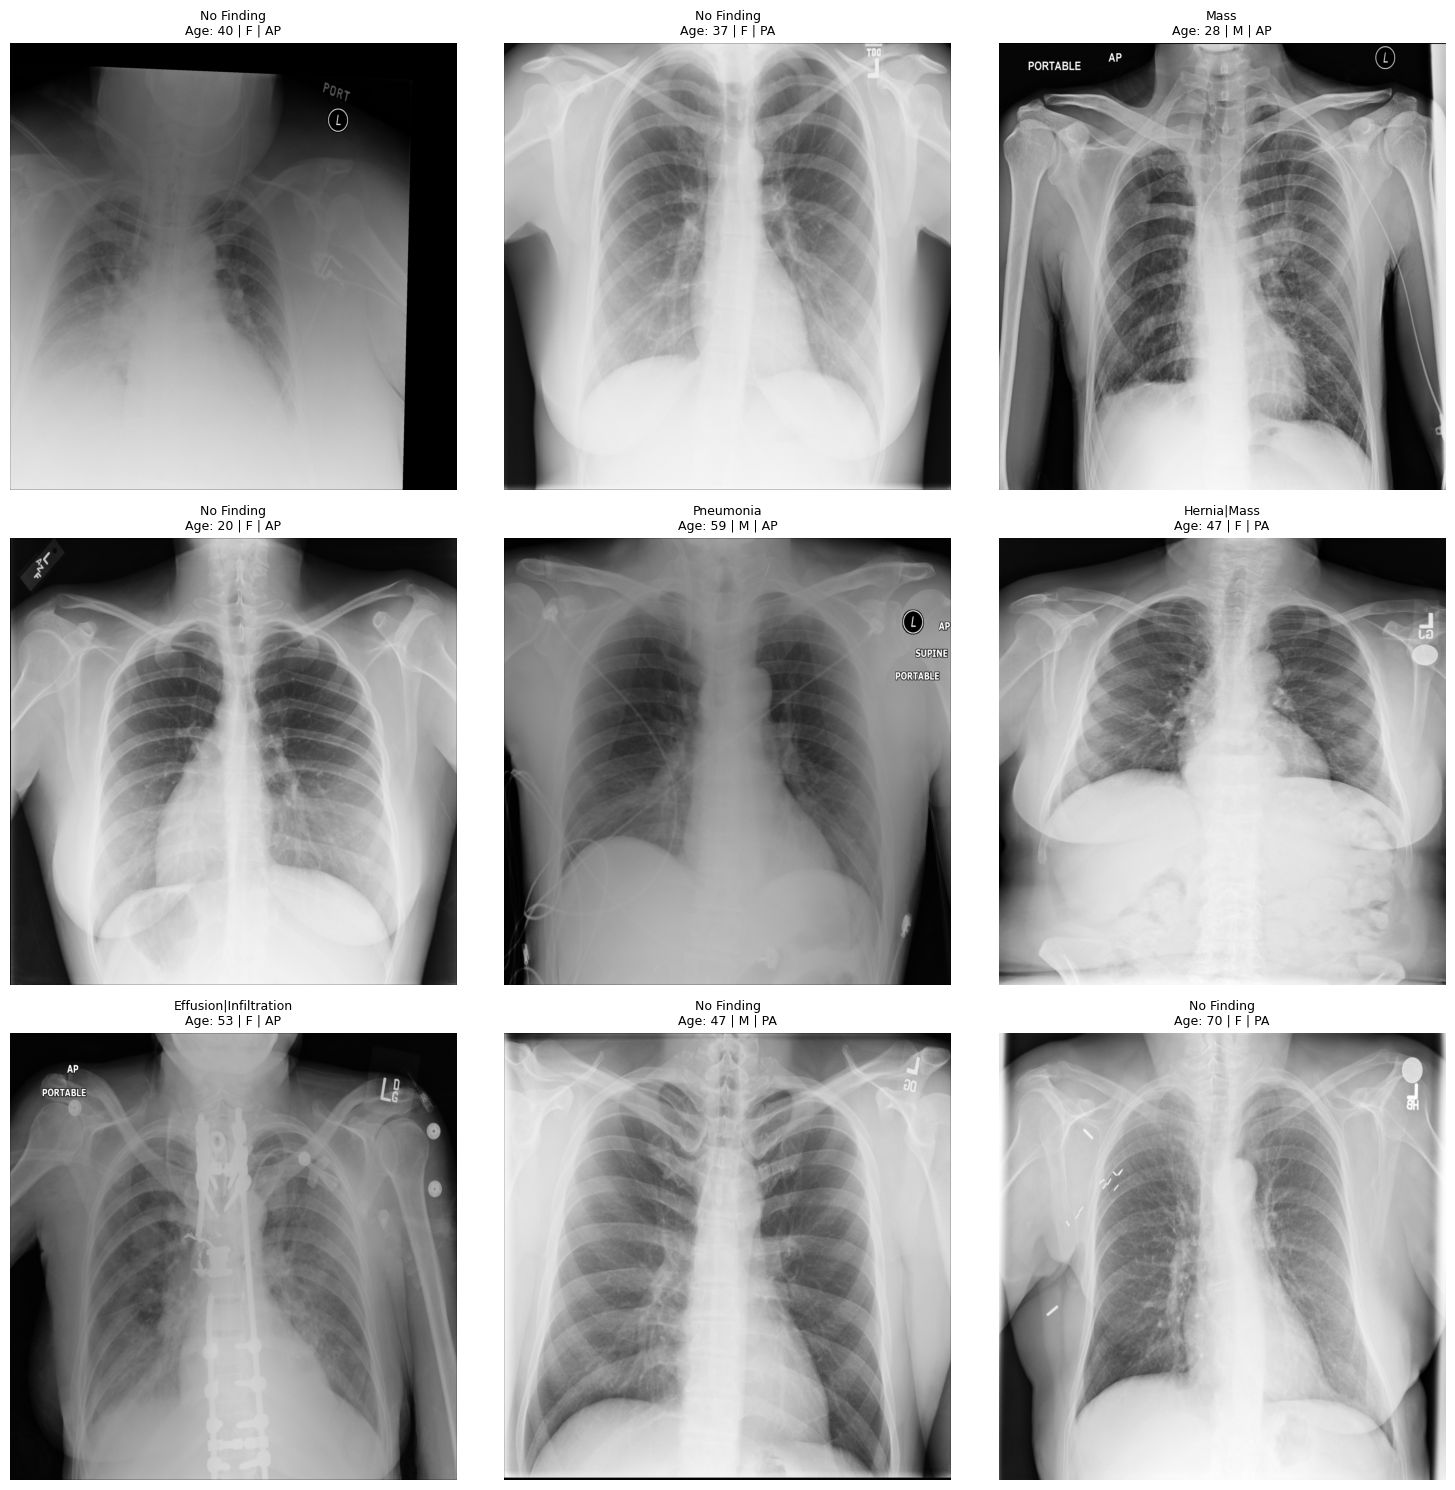

In [ ]:
import os
import matplotlib.pyplot as plt
from PIL import Image

image_dir = "/content/dataset/Chest_XRay_Dataset/xray_images"

sample_df = valid_df.sample(9, random_state=42)

plt.figure(figsize=(15, 15))

for i, (_, row) in enumerate(sample_df.iterrows()):

    image_path = os.path.join(
        image_dir,
        row["Image Index"]
    )

    img = Image.open(image_path)

    plt.subplot(3, 3, i + 1)

    plt.imshow(img, cmap="gray")

    plt.title(
        f'{row["Finding Labels"]}\n'
        f'Age: {row["Patient Age"]} | '
        f'{row["Patient Gender"]} | '
        f'{row["View Position"]}',
        fontsize=9
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

## 12. Patient-Level Train / Validation / Test Split

In [19]:
from sklearn.model_selection import GroupShuffleSplit

RANDOM_STATE = 42

# ---------------------------------------------------------
# Step 1: Split patients into 70% Train and 30% Temporary
# ---------------------------------------------------------

train_splitter = GroupShuffleSplit(
    n_splits=1,
    train_size=0.70,
    random_state=RANDOM_STATE
)

train_idx, temp_idx = next(
    train_splitter.split(
        valid_df,
        groups=valid_df["Patient ID"]
    )
)

train_df = valid_df.iloc[train_idx].copy()
temp_df = valid_df.iloc[temp_idx].copy()


# ---------------------------------------------------------
# Step 2: Split temporary set into 50% Validation and 50% Test
# This gives approximately:
# Train = 70%
# Validation = 15%
# Test = 15%
# ---------------------------------------------------------

val_test_splitter = GroupShuffleSplit(
    n_splits=1,
    train_size=0.50,
    random_state=RANDOM_STATE
)

val_idx, test_idx = next(
    val_test_splitter.split(
        temp_df,
        groups=temp_df["Patient ID"]
    )
)

val_df = temp_df.iloc[val_idx].copy()
test_df = temp_df.iloc[test_idx].copy()


# ---------------------------------------------------------
# Display split information
# ---------------------------------------------------------

print("Patient-level split completed.\n")

print(
    f"Train      : {len(train_df)} images | "
    f"{train_df['Patient ID'].nunique()} patients"
)

print(
    f"Validation : {len(val_df)} images | "
    f"{val_df['Patient ID'].nunique()} patients"
)

print(
    f"Test       : {len(test_df)} images | "
    f"{test_df['Patient ID'].nunique()} patients"
)

print("\nTotal images:", len(train_df) + len(val_df) + len(test_df))
print("Original images:", len(valid_df))

Patient-level split completed.

Train      : 2562 images | 717 patients
Validation : 563 images | 154 patients
Test       : 556 images | 154 patients

Total images: 3681
Original images: 3681


## 13. Verify Patient-Level Split and Check for Data Leakage

In [24]:
# Unique patients in each split
train_patients = set(train_df["Patient ID"])
val_patients = set(val_df["Patient ID"])
test_patients = set(test_df["Patient ID"])

# Check overlap
train_val_overlap = train_patients & val_patients
train_test_overlap = train_patients & test_patients
val_test_overlap = val_patients & test_patients

print("Patient overlap checks:")
print("-----------------------")
print("Train vs Validation:", len(train_val_overlap))
print("Train vs Test      :", len(train_test_overlap))
print("Validation vs Test :", len(val_test_overlap))

# Automatic validation
assert len(train_val_overlap) == 0, \
    "Leakage detected between Train and Validation!"

assert len(train_test_overlap) == 0, \
    "Leakage detected between Train and Test!"

assert len(val_test_overlap) == 0, \
    "Leakage detected between Validation and Test!"

print("\nPASSED: No patient leakage detected.")

Patient overlap checks:
-----------------------
Train vs Validation: 0
Train vs Test      : 0
Validation vs Test : 0

PASSED: No patient leakage detected.


## 14. Check Label Distribution Across Train, Validation, and Test

In [25]:
# Get all unique labels from the valid dataset
all_labels = sorted({
    label
    for labels in valid_df["Finding Labels"]
    for label in labels.split("|")
})

def get_label_distribution(data):
    distribution = {}

    for label in all_labels:
        count = data["Finding Labels"].apply(
            lambda x: label in x.split("|")
        ).sum()

        percentage = (count / len(data)) * 100

        distribution[label] = {
            "count": count,
            "percentage": percentage
        }

    return distribution


# Calculate distribution for each split
train_dist = get_label_distribution(train_df)
val_dist = get_label_distribution(val_df)
test_dist = get_label_distribution(test_df)


# Create comparison table
label_distribution_df = pd.DataFrame({
    "Train Count": [
        train_dist[label]["count"] for label in all_labels
    ],
    "Train %": [
        train_dist[label]["percentage"] for label in all_labels
    ],

    "Validation Count": [
        val_dist[label]["count"] for label in all_labels
    ],
    "Validation %": [
        val_dist[label]["percentage"] for label in all_labels
    ],

    "Test Count": [
        test_dist[label]["count"] for label in all_labels
    ],
    "Test %": [
        test_dist[label]["percentage"] for label in all_labels
    ]
}, index=all_labels)

display(label_distribution_df.round(2))

,Train Count,Train %,Validation Count,Validation %,Test Count,Test %
Atelectasis,222,8.75,56,9.33,48,8.82
Cardiomegaly,62,2.44,15,2.50,18,3.31
Consolidation,115,4.53,21,3.50,20,3.68
Edema,39,1.54,6,1.00,12,2.21
Effusion,211,8.32,36,6.00,40,7.35
Emphysema,48,1.89,16,2.67,9,1.65
Fibrosis,83,3.27,29,4.83,13,2.39
Hernia,4,0.16,2,0.33,3,0.55
Infiltration,410,16.16,95,15.83,100,18.38
Mass,72,2.84,16,2.67,17,3.12


## 15. Optimize Patient-Level Split for Label Balance

In [22]:
import numpy as np
from sklearn.model_selection import GroupShuffleSplit

# ---------------------------------------------------------
# Prepare all labels
# ---------------------------------------------------------

all_labels = sorted({
    label
    for labels in valid_df["Finding Labels"]
    for label in labels.split("|")
})


def label_prevalence(data):
    """Return prevalence of every label in a dataframe."""

    prevalence = []

    for label in all_labels:
        count = data["Finding Labels"].apply(
            lambda x: label in x.split("|")
        ).sum()

        prevalence.append(count / len(data))

    return np.array(prevalence)


# Overall dataset distribution
overall_prevalence = label_prevalence(valid_df)


# ---------------------------------------------------------
# Function to score a patient-level split
# Lower score = better label balance
# ---------------------------------------------------------

def split_balance_score(train, val, test):

    train_prev = label_prevalence(train)
    val_prev = label_prevalence(val)
    test_prev = label_prevalence(test)

    train_diff = np.abs(train_prev - overall_prevalence)
    val_diff = np.abs(val_prev - overall_prevalence)
    test_diff = np.abs(test_prev - overall_prevalence)

    return (
        train_diff.mean()
        + val_diff.mean()
        + test_diff.mean()
    )


# ---------------------------------------------------------
# Try many patient-level splits
# ---------------------------------------------------------

best_score = float("inf")
best_split = None
best_seed = None

for seed in range(500):

    # 70% Train / 30% Temporary
    splitter1 = GroupShuffleSplit(
        n_splits=1,
        train_size=0.70,
        random_state=seed
    )

    train_idx, temp_idx = next(
        splitter1.split(
            valid_df,
            groups=valid_df["Patient ID"]
        )
    )

    candidate_train = valid_df.iloc[train_idx].copy()
    candidate_temp = valid_df.iloc[temp_idx].copy()


    # Split remaining 30% into 15% Validation / 15% Test
    splitter2 = GroupShuffleSplit(
        n_splits=1,
        train_size=0.50,
        random_state=seed
    )

    val_idx, test_idx = next(
        splitter2.split(
            candidate_temp,
            groups=candidate_temp["Patient ID"]
        )
    )

    candidate_val = candidate_temp.iloc[val_idx].copy()
    candidate_test = candidate_temp.iloc[test_idx].copy()


    # Avoid splits where a label disappears completely
    valid_candidate = True

    for label in all_labels:

        train_count = candidate_train["Finding Labels"].apply(
            lambda x: label in x.split("|")
        ).sum()

        val_count = candidate_val["Finding Labels"].apply(
            lambda x: label in x.split("|")
        ).sum()

        test_count = candidate_test["Finding Labels"].apply(
            lambda x: label in x.split("|")
        ).sum()

        if train_count == 0 or val_count == 0 or test_count == 0:
            valid_candidate = False
            break

    if not valid_candidate:
        continue


    score = split_balance_score(
        candidate_train,
        candidate_val,
        candidate_test
    )

    if score < best_score:

        best_score = score
        best_seed = seed

        best_split = (
            candidate_train,
            candidate_val,
            candidate_test
        )


# ---------------------------------------------------------
# Use best split
# ---------------------------------------------------------

if best_split is not None:

    train_df, val_df, test_df = best_split

    print("Best patient-level split found.")
    print("Best random seed:", best_seed)
    print("Balance score:", round(best_score, 6))

    print()
    print(
        f"Train      : {len(train_df)} images | "
        f"{train_df['Patient ID'].nunique()} patients"
    )

    print(
        f"Validation : {len(val_df)} images | "
        f"{val_df['Patient ID'].nunique()} patients"
    )

    print(
        f"Test       : {len(test_df)} images | "
        f"{test_df['Patient ID'].nunique()} patients"
    )

else:

    print("No suitable split was found.")

Best patient-level split found.
Best random seed: 178
Balance score: 0.014644

Train      : 2537 images | 717 patients
Validation : 600 images | 154 patients
Test       : 544 images | 154 patients


## 16. Save Final Patient-Level Dataset Splits

In [26]:
# Save final patient-level splits

train_df.to_csv(
    "/content/train_patient_split.csv",
    index=False
)

val_df.to_csv(
    "/content/validation_patient_split.csv",
    index=False
)

test_df.to_csv(
    "/content/test_patient_split.csv",
    index=False
)

print("Final patient-level splits saved successfully.")

print(f"Train      : {len(train_df)} images | {train_df['Patient ID'].nunique()} patients")
print(f"Validation : {len(val_df)} images | {val_df['Patient ID'].nunique()} patients")
print(f"Test       : {len(test_df)} images | {test_df['Patient ID'].nunique()} patients")

Final patient-level splits saved successfully.
Train      : 2537 images | 717 patients
Validation : 600 images | 154 patients
Test       : 544 images | 154 patients


single patient-assignment file. This makes it very easy to prove later that a patient belongs to exactly one partition

In [29]:
patient_split_df = pd.concat([
    train_df[["Patient ID"]].drop_duplicates().assign(Split="Train"),
    val_df[["Patient ID"]].drop_duplicates().assign(Split="Validation"),
    test_df[["Patient ID"]].drop_duplicates().assign(Split="Test")
])

patient_split_df = patient_split_df.sort_values("Patient ID")

patient_split_df.to_csv(
    "/content/patient_split_assignments.csv",
    index=False
)

display(patient_split_df.head(10))

print("\nPatients saved:", len(patient_split_df))

,Patient ID,Split
30,250,Train
41,251,Train
46,252,Train
48,253,Train
49,254,Validation
52,255,Test
58,256,Train
60,258,Validation
61,259,Train
62,260,Train



Patients saved: 1025


## 17. Summary and Next Steps

### Summary

This analysis explored and prepared a chest X-ray dataset for future multi-label image classification.

Key findings:

- The metadata contains **111,010 X-ray records**.
- The dataset represents **30,538 unique patients**.
- There are **15 unique labels**, including 14 chest findings and `No Finding`.
- A single X-ray may contain multiple findings, making this a **multi-label classification problem**.
- The complete metadata is highly imbalanced across findings.
- The provided image archive contains **3,710 PNG images**.
- **3,681 images** have matching ground-truth metadata and form the usable dataset.
- **29 images** do not have matching CSV metadata and are excluded.
- Multiple X-rays can belong to the same patient; therefore, patient-level train, validation, and test splitting was implemented using GroupShuffleSplit to prevent data leakage.
- The final patient-level split contains 2,537 training images from 717 patients, 600 validation images from 154 patients, and 544 test images from 154 patients.
- Leakage validation confirmed zero patient overlap between train, validation, and test datasets.
- Label distribution was evaluated and optimized to maintain a more balanced representation of findings across all splits.
- Final patient-level splits were saved for reproducible future model training and evaluation.
